# Preambule and notes

**Notes 06/08/25**
- improve particles displacement nearest-neighbors -> interpolation in numba or openmp + pybind11
- Be consistent: eg if I solve $\gamma_k$ for below the Nyquist frequency, calculate $\Phi_k$ and solve the displacement also in this range
- 512^3 particles is hard for for a proof of concept test (maybe use fastpm as solver and low res Quijote as ref + syren)
- check if I take the other $\gamma_k$ roots the correlation in k space increases or not
- Hybrid: convolve ICs with emulator Pk to match phases/high scales or (dirty) do not resolve below given k
- when I interpolate in k-space, I need to incorporate the kernel for linear interpolation that is the inverse of CiC
- unless necessary, do not put a threshold on grad_phi in comoving space
- can we use this code for a halo case later ? (to pursue Anirban's examples)

In [36]:
!pip install numba==0.60.0

  Using cached numba-0.60.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
  Using cached llvmlite-0.43.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.8 kB)
Using cached numba-0.60.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
Using cached llvmlite-0.43.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (43.9 MB)
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninstalled llvmlite-0.44.0
  Attempting uninstall: numba━━━━━━━━━━━━━━━━━━━ 0/2 [llvmlite]
    Found existing installation: numba 0.61.2 0/2 [llvmlite]
    Uninstalling numba-0.61.2:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
      Successfully uninstalled numba-0.61.2━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]


In [1]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from funcs import get_delta, compute_Pk, compute_Bk,calculate_acc_from_phi_k, correct_pos, compute_XPk, get_roots,MAS_correction, terms_root, get_roots_gamma, terms_root_gamma, get_roots_overdensity
import scipy
import h5py, itertools
from scipy.fft import *

import progressbar
import inspect
import os
from sys import getsizeof

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.colors as colors
import colorsys
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Circle, Rectangle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
import matplotlib.ticker as mtick

# Pylians
import readgadget
import MAS_library as MASL
import Pk_library as PKL
import plotting_library as PL
import smoothing_library as SL

# Emulators
import symbolic_pofk.syrenhalofit as syrenhalofit
import symbolic_pofk.linear as linear
import astropy.cosmology as cosmo

# Conveniences
format_float = lambda z: "%ip%i"%(int(z // 1), int(z%1 *10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return a + r"$\times 10^{%i}$"%b

plt.style.use("dark_background")

import time
np.__version__

--------------------------------------------------------------------------

  Local host:   a244
  Local device: mlx5_0
--------------------------------------------------------------------------
[a244.anvil.rcac.purdue.edu:2567936] common_ucx.c:362  Warning: UCX is unable to handle VM_UNMAP event. This may cause performance degradation or data corruption. Pls try adding --mca opal_common_ucx_opal_mem_hooks 1 to mpirun/oshrun command line to resolve this issue.


'1.23.5'

In [2]:
# For opti tests
import pyfftw
import numba
from numba import njit, jit

In [3]:
import psutil
from psutil._common import bytes2human
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())

total memory: 251.5G
memory % used: 15.8
number of cpus : 128


# 0) Very brief summary
**A handful of equation for different test cases**

The goal is to perturbed particles positions 

\begin{align}
\mathbf{x}_i' = \mathbf{x}_i + \nabla\phi(\mathbf{x}_i)
\end{align}

We use the convention that $\Delta$ designates the fractional overdensity field, meaning in comoving space

$\Delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \rho_\text{mean}}{\rho_\text{mean}}$
with $\rho(\mathbf{x}) = \sum_{i=1}^n \delta(\mathbf{x} - \mathbf{x}_i)$ defined with the Delta function.

The main equation for the Fourier transform of the density field of the perturbed tracer $\Delta_k^{'}$ is

\begin{align}
|\Delta^{'}_\mathbf{k}|^2 &= \Delta^{'}_\mathbf{k}\Delta^{' \ast}_\mathbf{k}  \\
&= \left[ \Delta_\mathbf{k} + k^2\phi_{\mathbf{k}} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}} 
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}  
\right) \right] \times \nonumber\\
&\left[\Delta^{\ast}_\mathbf{k} + k^2\phi_{\mathbf{k}}^{\ast} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber\\
|\Delta^{'}_\mathbf{k}|^2 &\approx_{\mathcal{O}(\phi^2)} |\Delta_{\mathbf{k}}|^2 + k^4 |\phi_{\mathbf{k}}|^2 + \frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \phi_{\mathbf{q}}
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast} \nonumber\\
 &+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\phi_{\mathbf{k}}^{\ast} +\frac{k^2}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{k}}\phi_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber 
\end{align}

# 1) Setup and load data
The Quijote fiducial simulations parameters are reminded in the [documentation](https://quijote-simulations.readthedocs.io/en/latest/types.html). 
We will try to perturb a L-PICOLA snapshot, with the reference being either the Quijote simulation at the same seed or from the [symbolik_pofk](https://github.com/DeaglanBartlett/symbolic_pofk) emulator.

In [4]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8":0.834, "n_s":0.9624, "h":0.671, "Omega_b":0.049,
            "Omega_m":0.3175}

In [5]:
os.makedirs?

Signature: os.makedirs(name, mode=511, exist_ok=False)
Docstring:
makedirs(name [, mode=0o777][, exist_ok=False])

Super-mkdir; create a leaf directory and all intermediate ones.  Works like
mkdir, except that any intermediate path segment (not just the rightmost)
will be created if it does not exist. If the target directory already
exists, raise an OSError if exist_ok is False. Otherwise no exception is
raised.  This is recursive.
File:      ~/miniconda3/envs/pkcorr/lib/python3.10/os.py
Type:      function

In [6]:
redshift = 0.5
a = 1 / (1+redshift)
z_str = format_float(redshift)
seed = 1

nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003"%(z_str,seed)
nbodystr = "Quijote"

app = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500"%(z_str,seed)
appstr = "LPICOLA"
ptype   = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

basedir = "/home/x-nchartier/PkCorr/Figures"

if not os.path.exists(os.path.join(basedir, appstr)):
    os.makedirs(os.path.join(basedir, appstr), exist_ok=False)

# TODO: test on fastpm sims with saved DM particles
# fpm = "/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/%i/"%seed
# file = h5py.File(os.path.join(fpm, "nbody.h5"))
# print(file.keys())
# data = file['0.666667']
# print(data.keys())
# file.close()

In [7]:
# read header for nbody
header   = readgadget.header(nbody)
BoxSize  = header.boxsize/1e3  #Mpc/h
print("BoxSize = %.1f Mpc"%BoxSize)
Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3)
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
print(r"$\Omega_m = %.4f$"%Omega_m)
Omega_l  = header.omega_l      #value of Omega_l
print(r"$\Omega_{\Lambda} = %.4f$"%Omega_l)
h        = header.hubble       #value of h
print(r"$h=%.4f$"%h)
#redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble)
Hubble_0   = 100.0*np.sqrt(Omega_m+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble_0)
print(h*Hubble_0)

# read positions, velocities and IDs of the particles
pos_nb = readgadget.read_block(nbody, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_nb = readgadget.read_block(nbody, "VEL ", ptype)     #peculiar velocities in km/s
#ids_nb = readgadget.read_block(nbody, "ID  ", ptype)-1   #IDs starting from 0

BoxSize = 1000.0 Mpc
[1.]
$\Omega_m = 0.3175$
$\Omega_{\Lambda} = 0.6825$
$h=0.6711$
132.44102461095656
100.0
67.11


In [8]:
# read header for nbody
header   = readgadget.header(app)

Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3) # sanity check

# read positions, velocities and IDs of the particles
pos_pm = readgadget.read_block(app, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_pm = readgadget.read_block(app, "VEL ", ptype)     #peculiar velocities in km/s
#ids_pm = readgadget.read_block(app, "ID  ", ptype)-1   #IDs starting from 0

[1.]


Compute overdensity fields and Power spectra from snapshots

In [9]:
grid = 256
BoxSize=1000.0 # Mpc/h
voxel_size = np.array(3*[BoxSize/grid])
MAS='CIC'
MAS_index=2

# PM
delta_pm = get_delta(pos=pos_pm, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_pm, Pk_pm, _, _ = compute_Pk(delta_pm, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# N-body (=target if no emulator)
delta_nb = get_delta(pos=pos_nb, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_nb, Pk_nb, _, _ = compute_Pk(delta_nb, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X, Pk_X, _, _ = compute_XPk(delta_pm, delta_nb, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rk = Pk_X/np.sqrt(Pk_pm*Pk_nb)


Using CIC mass assignment scheme
Time taken = 1.806 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds

Using CIC mass assignment scheme
Time taken = 1.845 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds

Computing power spectra of the fields...
Time FFTS = 0.56
Time loop = 0.36
Time taken = 0.93 seconds


In [10]:
def plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptypes, plane, MAS, scale, 
                 colmap, dmin, dmax, redshift, titleList):  
    """
    Plot projected density (or overdensity) field for each snapshot in snapList 
    """ 
    W_k = SL.FT_filter_2D(x_max - x_min, 0, grid, "Top-Hat", 5)
    P = len(snapList)
    save_density_field = False
    
    #Initialize axes depending on the number of snapshots to analyze
    if P%2 == 0 and P > 2:
      fig, axes = plt.subplots(int(P/2), int(P/2), sharex = False, sharey = False, squeeze = False, figsize = (12,12))
    else:
      fig, axes = plt.subplots(1, P, sharex = False, sharey = False, squeeze = False, figsize = (14, 9))
      axes.shape

    #To have the same colorbar scales for all plots, we need to compute all the overdensities
    OD_list = []
    for k in np.arange(0,P):
       dx, x, dy, y, overdensity = PL.density_field_2D(snapList[k], x_min, x_max, y_min, y_max, z_min, z_max, 
                                                       grid, ptypes, plane, MAS, save_density_field) # For Pylians3
       
       #overdensity[np.where(overdensity == 0)] = np.sort(np.unique(overdensity))[1] #prevents errors with log norm
       overdensity[np.where(overdensity < dmin)] = dmin
       overdensity[np.where(overdensity > dmax)] = dmax
       overdensity = SL.field_smoothing_2D(overdensity, W_k, 4)
       OD_list.append(overdensity)

    min_OD = min(overdensity.min() for overdensity in OD_list)
    max_OD = max(overdensity.max() for overdensity in OD_list)
    
    #For each snapshot  
    for k in np.arange(0, P):
        len_x, off_x, len_y, off_y, depth, BoxSize_slice = PL.geometry(snapList[k], plane, x_min, x_max, y_min, 
                                                                       y_max, z_min, z_max)
        #Compute overdensity field with Pylians plotting library
        ax = axes.flat[k] #flat not to bother with the 2D case
        ax.set_xlim([off_x, off_y+len_x])  #set the range for the x-axis
        ax.set_ylim([off_y, off_y+len_y])  #set the range for the y-axis
        ax.set_xlabel(r'$h^{-1}{\rm Mpc}$',fontsize= 24, labelpad = 5)  #x-axis label     
        ax.set_title(titleList[k], fontsize = 22)
        ax.tick_params(axis='x', which='major', pad=2, labelsize = 22)
        ax.tick_params(axis='y', which='major', pad=2, labelsize = 22)
        
        if scale == "linear":
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     vmin=min_OD,vmax=max_OD)
            
        else:   
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     norm = LogNorm(vmin=min_OD, vmax=max_OD))
        
        #next lines adjust the colorbar dimensions next to the subplot
        divider = make_axes_locatable(ax)
        cad = divider.append_axes("right", size="8%", pad=0.05)
        plt.subplots_adjust(bottom = 0.1, top = 0.9, left = 0.09, right = 0.94, wspace = 0.35)
        cbar = plt.colorbar(ca, cax=cad)
        cbar.ax.tick_params(axis = "both", labelsize = 22)      


Computing density field...
Expected mass = 1.1220728e+18
Computed mass = 1.1220731e+18
mass density = 8.81221e+10
0.087317914 < rho/<rho> < 23.772453

Computing density field...
Expected mass = 1.1222171e+18
Computed mass = 1.1222175e+18
mass density = 8.81221e+10
0.13087106 < rho/<rho> < 18.21459


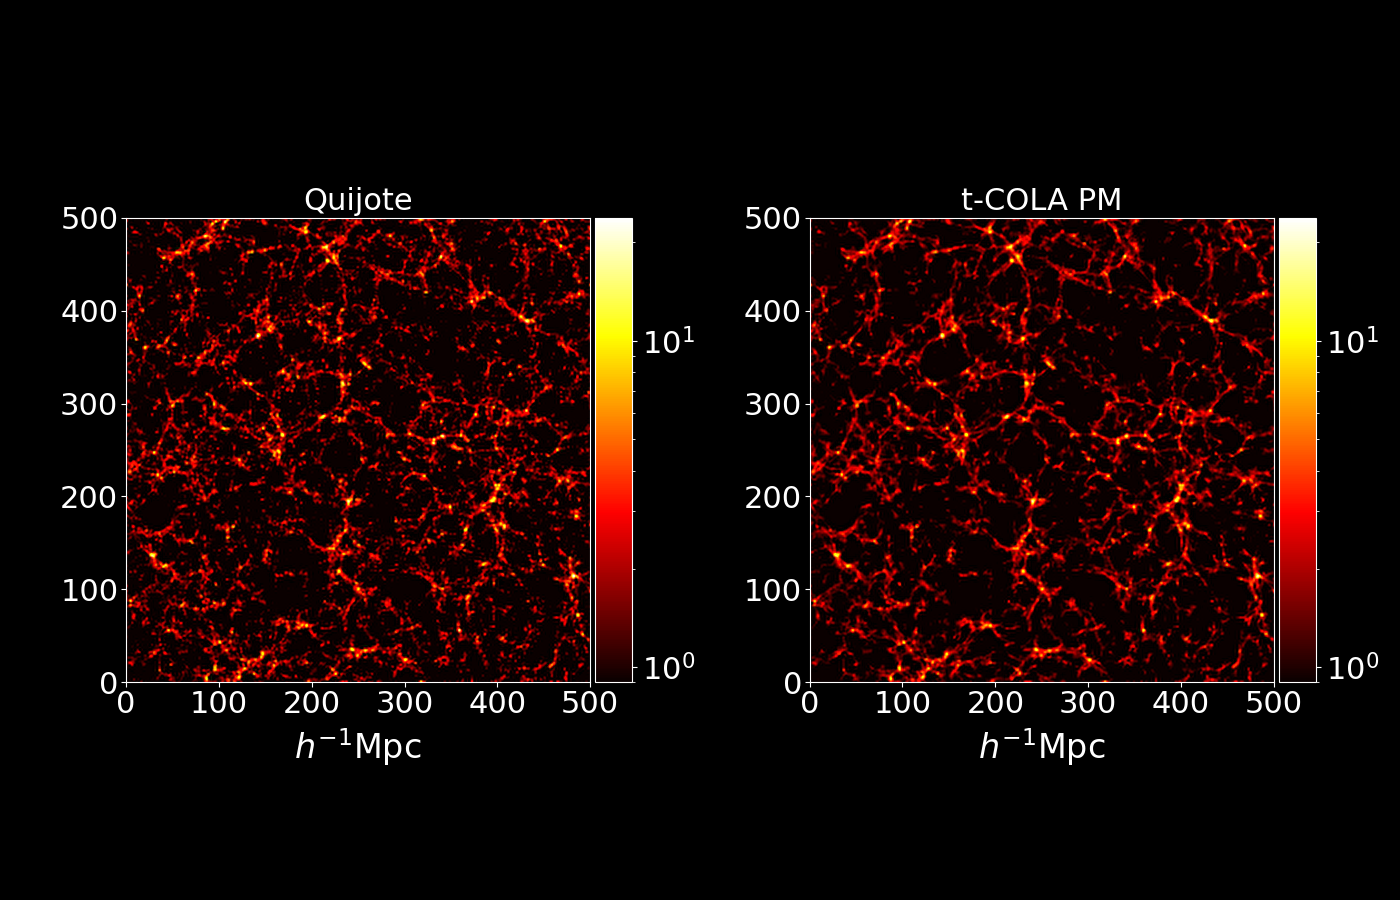

In [11]:
snapList = [nbody, app]
# For plotting
kNyquist = 0.5 * grid/BoxSize
indicateNyquist = False
dmin = 0.9
dmax = 80
#%% 2D PROJECTED OVERDENSITY FIELD 

x_min = 0.0;  x_max = 500.0
y_min = 0.0;  y_max = 500.0
z_min = 40.0;  z_max = 90.0

plane = 'XY'
scale = 'log' #'linear' or 'log'
colmap = 'hot'
#colmap = "YlGnBu"
#colmap = "BuPu"
save_density_field = False
axList = ["Quijote", "t-COLA PM"]

plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptype, plane, MAS, scale, colmap,
                dmin, dmax, redshift, axList)

In [12]:
# Emulate P(k)
pk_halofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial',
                extrapolate=True, which_params='Bartlett', add_correction=False)

pk_syrenhalofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                    Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial', 
                    extrapolate=True, which_params='Bartlett', add_correction=True)



/home/x-nchartier/miniconda3/envs/pkcorr/lib/python3.10/site-packages/symbolic_pofk/linear.py:244: UserWarning: Using Bartlett et al. formula outside tested regime. Due to problems with the Colossus Eisenstein & Hu fit on                 large scales (typically a 2 percent offset), it is strongly recommended to use extrapolate=False.
  warnings.warn(


In [13]:
# Pylians uses the diagonal of the cube for kmax, not k Nyquist !
print(k_pm.max())
print(k_pm.shape)
print(np.pi *grid/BoxSize)
print(np.pi *grid/BoxSize * np.sqrt(3))

1.3902843163141774
(221,)
0.8042477193189871
1.3929979117318794


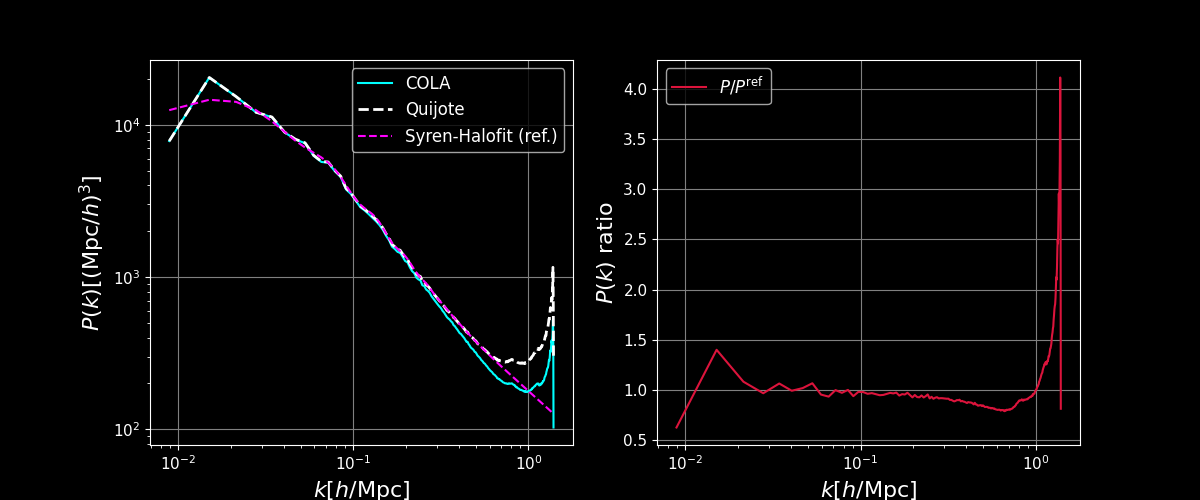

In [14]:
#plt.style.use("default")
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "white", zorder = 4)
ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "--", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)

ax2.plot(k_pm, Pk_pm/pk_syrenhalofit, label='$P/P^{\mathrm{ref}}$', zorder = 3, color = "crimson")
ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.tick_params(labelsize = 11)

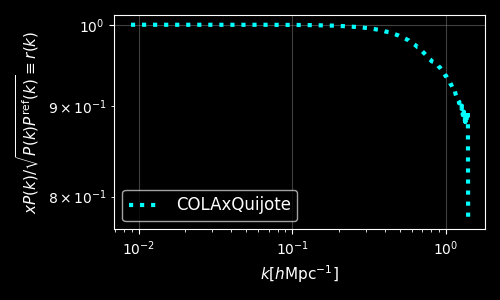

In [15]:
fig, axes = plt.subplots(1,1, figsize = (5,3))
axes.plot(k_X, rk, ':', label='COLAxQuijote', zorder= 10, lw = 3, color = "cyan")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()

# 2) Dark matter perturbation tests

## 2-1) Perfect correlation case
$\Phi(k) = \frac{\gamma_k}{k^2} \Delta_k$

Pick sign of gamma k so that we move towards higher density locations

If we take the expectation with respect to Delta, power spectrum, as well as bispectum and trispectrum terms appear

\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} &\approx (2\pi)^3P(k) + \gamma_k^2(2\pi)^3P(k) +\frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} \frac{\gamma_{q'}\gamma_{q}}{q^2 q'^{2}}(\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}
 \Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast}] \nonumber \\
&+ 2 \operatorname{Re}\left[ (2\pi)^3 \gamma_k P(k) +\frac{1}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \gamma_k \frac{\gamma_q}{q^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}] \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}]
    +\frac{1}{2V} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot (\mathbf{k} -\mathbf{q}))\frac{\gamma_q}{q^2} \frac{\gamma_{|k-q|}}{|k-q|^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{k-q}}^{\ast}]
 \right. \nonumber \\
 &+ \left. \frac{1}{2V^2} \sum_{\mathbf{q}, \mathbf{q'}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot \mathbf{q'})\frac{\gamma_q}{q^2} \frac{\gamma_q'}{q'^2}\mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast}] \right]
\end{align}

**Question**

Can we afford dropping bispectrum and trispectrum terms and simply solving for the polynomial below ? 
\begin{equation}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} = P(k) + \gamma_k^2 P(k) + 2 \gamma_k P(k) 
\end{equation}

In [16]:
# If emulator, the target Power spectrum is a mean emulator calculation
emulator = False
Pk_target = pk_syrenhalofit if emulator else Pk_nb
high_roots = True # take roots_e[:,1].real if True, roots_e[:,0].real otherwise
tstr = "emul" if emulator else "sim"
rstr = "posroots" if high_roots else "negroots"
fig_fold = os.path.join(basedir, appstr, "corr_%s_%s"%(tstr, rstr))

if not os.path.exists(fig_fold):
    os.makedirs(os.path.join(fig_fold), exist_ok=False)

# Limit the analysis to k Nyquist
kN = np.pi *grid/BoxSize
inds = np.where(k_nb <= kN)
k = k_nb[inds]
print(k.shape)

(127,)


(127, 3)


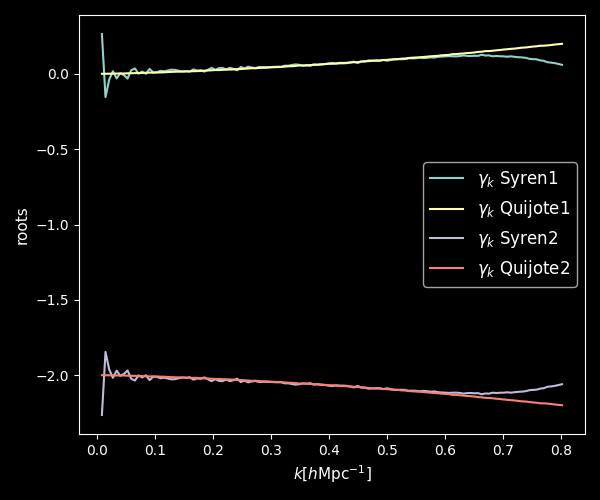

In [17]:
# With gamma convention
roots_nb, coeffs_nb=get_roots_gamma(k, Pk_pm[inds], Pk_nb[inds])
roots_e, coeffs_e=get_roots_gamma(k, Pk_pm[inds], pk_syrenhalofit[inds])

# "Positive" roots
gamma_k_e1 = roots_e[:,1].real
gamma_k_nb1 = roots_nb[:,1].real

# "Lower" roots
gamma_k_e2 = roots_e[:,0].real
gamma_k_nb2 = roots_nb[:,0].real
print(coeffs_e.shape)

fig, ax = plt.subplots(figsize = (6,5), ncols = 1, nrows= 1)
ax.plot(k, gamma_k_e1, label=r'$\gamma_k$' + " Syren1")
ax.plot(k, gamma_k_nb1, label=r'$\gamma_k$' + " Quijote1")
ax.plot(k, gamma_k_e2, label=r'$\gamma_k$' + " Syren2")
ax.plot(k, gamma_k_nb2, label=r'$\gamma_k$' + " Quijote2")
ax.legend(fontsize = 12)
ax.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
ax.set_ylabel(r"roots", fontsize = 11)
plt.tight_layout()

# Sets the roots for later with the same variable names
if emulator:
    Pk_target = pk_syrenhalofit
    gamma_k = gamma_k_e1 if high_roots else gamma_k_e2
    coeffs = coeffs_e
    roots = roots_e
else:
    Pk_target = Pk_nb
    gamma_k = gamma_k_nb1 if high_roots else gamma_k_nb2
    coeffs = coeffs_nb
    roots = roots_nb

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

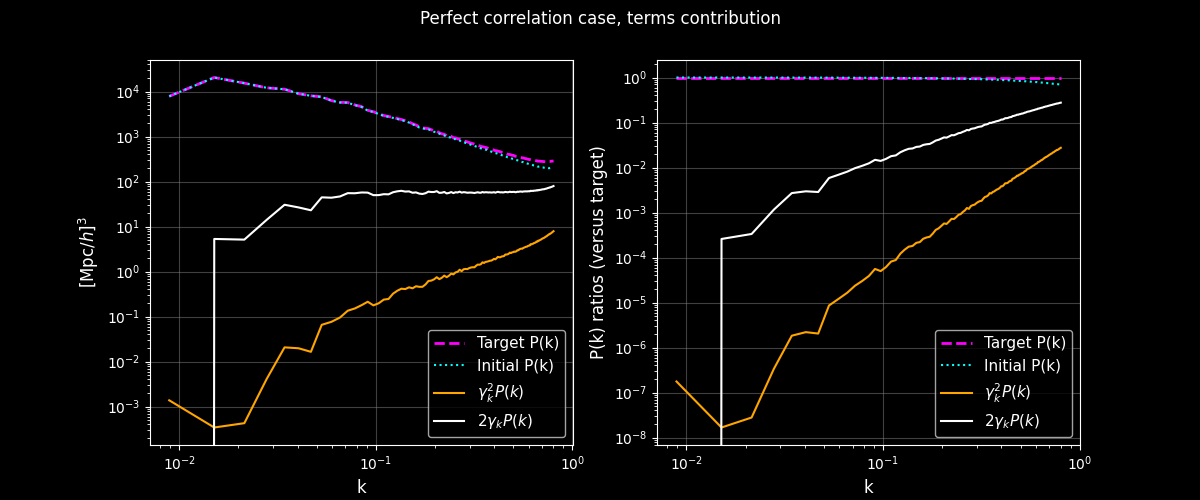

In [18]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k, Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")

### FFT tests and plots: MAS and k radius
I take the occasion to compare the computation times for two different ways of using pyfftw.

In [19]:
# Perform the FFT for delta(k)
#N_CPU = 16
prec_dict = {"float32":"complex64", "float64": "complex128"}
prec_in ="float32"
prec_out = prec_dict[prec_in]

NCPU_list = [1,2,4,8,16,32]
ct1_list = []
ct2_list = []
ct3_list = []

for N_CPU in NCPU_list:
    
    start = time.time()
    # Initialize
    arr_in  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    # Fill data in advance with builders interface
    arr_in[:] =  delta_pm.astype(prec_in)
    # Instantiate FFTW object
    fftw_object = pyfftw.builders.rfftn(arr_in,  axes=(0,1,2), threads=N_CPU)
    # Compute transform
    delta_pm_fourier_alt = fftw_object()
    end = time.time()
    print("First computation: %.3f seconds"%(end-start))
    ct1_list.append(end-start)
    
    # ALTERNATIVE COMPUTATION
    start = time.time()
    a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
    a_out = pyfftw.empty_aligned((grid,grid,grid//2+1),dtype='complex64')
    # plan FFTW
    fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                            flags=('FFTW_ESTIMATE',),
                            direction='FFTW_FORWARD', threads=N_CPU)
    # put input array into delta_r and perform FFTW
    a_in[:] = delta_pm.astype(prec_in)
    delta_pm_fourier = fftw_plan(a_in,a_out)
    end = time.time()
    ct2_list.append(end-start)
    print("Second computation: %.3f seconds"%(end-start))

    # With numpy interface
    start = time.time()
    delta_pm_fourier_np = pyfftw.interfaces.numpy_fft.rfftn(delta_pm.astype(prec_in))
    end = time.time()
    ct3_list.append(end-start)
    print("Numpy interface: %.3f seconds"%(end-start))

    print("Norm of difference fftw 2 methods: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_alt)))
    print("Norm of difference fftw np: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_np)), "\n")

    if N_CPU != NCPU_list[-1]:
        del delta_pm_fourier, delta_pm_fourier_alt, arr_in, a_in, fftw_object, fftw_plan


print("Norm of difference fftw 2 methods: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_alt)))
print("Norm of difference fftw np: %.3f"%(np.linalg.norm(np.fft.fftshift(delta_pm_fourier)-np.fft.fftshift(delta_pm_fourier_np))), "\n")    
del delta_pm_fourier_alt, delta_pm_fourier_np

First computation: 0.319 seconds
Second computation: 0.280 seconds
Numpy interface: 0.304 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.191 seconds
Second computation: 0.166 seconds
Numpy interface: 0.303 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.135 seconds
Second computation: 0.102 seconds
Numpy interface: 0.301 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.113 seconds
Second computation: 0.082 seconds
Numpy interface: 0.304 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.099 seconds
Second computation: 0.069 seconds
Numpy interface: 0.308 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.105 seconds
Second computation: 0.068 seconds
Numpy interface: 0.307 seconds
Norm of difference fftw 2 m

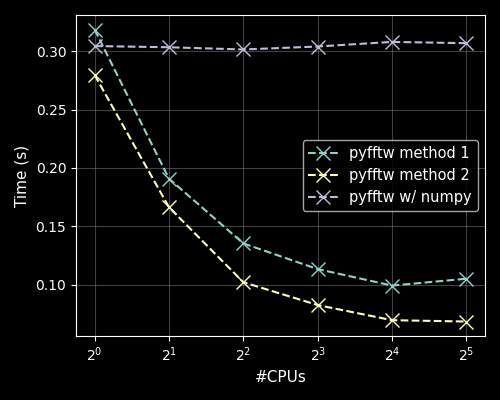

In [20]:
fig, ax = plt.subplots(figsize = (5,4))
ax.plot(NCPU_list, ct1_list, label = "pyfftw method 1", marker ="x", markersize = 10, ls="--")
ax.plot(NCPU_list, ct2_list, label = "pyfftw method 2", marker ="x", markersize = 10, ls="--")
ax.plot(NCPU_list, ct3_list, label = "pyfftw w/ numpy", marker ="x", markersize = 10, ls="--")
ax.set_xscale('log', base=2)
ax.set_ylabel("Time (s)", fontsize = 11)
ax.set_xlabel("#CPUs", fontsize = 11)
ax.set_yscale('linear')
ax.legend(fontsize = 10.5, loc = "best")
ax.grid(color = "gray", alpha =0.5)
plt.tight_layout()

About np.meshgrid:
In the 2-D case with inputs of length M and N, the outputs are of shape (N, M) for ‘xy’ indexing and (M, N) for ‘ij’ indexing. In the 3-D case with inputs of length M, N and P, outputs are of shape (N, M, P) for ‘xy’ indexing and (M, N, P) for ‘ij’ indexing

In [21]:
def fourier_shells_k(res, box_size, fshift = True):
    '''
    Use fhsift=True to move the zero frequency component at the center of arrays
    '''
    scale = 2*np.pi*res/box_size # k resolution
    if fshift:
        k_x = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_y = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_z = np.array(scale*np.fft.rfftfreq(res), dtype='float32') # not fftshift for redundant "refreq" case
    else:
        k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_y = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_z = np.array(scale*np.fft.rfftfreq(res), dtype='float32')

    kx, ky, kz = np.meshgrid(k_x, k_y, k_z, indexing='ij')
    k_radius_grid = np.sqrt(kx**2 + ky**2 + kz**2)
        
    return k_x, k_y, k_z, k_radius_grid

# Keep fftshift True for consistency later on
fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
kx_g, ky_g, kz_g = np.meshgrid(kx_v, ky_v, kz_v, indexing = "ij")
print(k_radius.shape)
print(k_radius.max())
print(kx_v.min(), kx_v.max())

# Compute MAS correction factors - we first need 3d arrays
MAS_factor_kx = MAS_correction(kx_g, MAS_index)
MAS_factor_ky = MAS_correction(ky_g, MAS_index)
MAS_factor_kz = MAS_correction(kz_g, MAS_index)

MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz
del MAS_factor_kx, MAS_factor_ky, MAS_factor_kz
print(delta_pm_fourier.dtype)
print(abs(delta_pm_fourier).min(), abs(delta_pm_fourier).max())

(256, 256, 129)
1.392998
-0.80424774 0.7979645
complex64
0.0040893555 186201.84


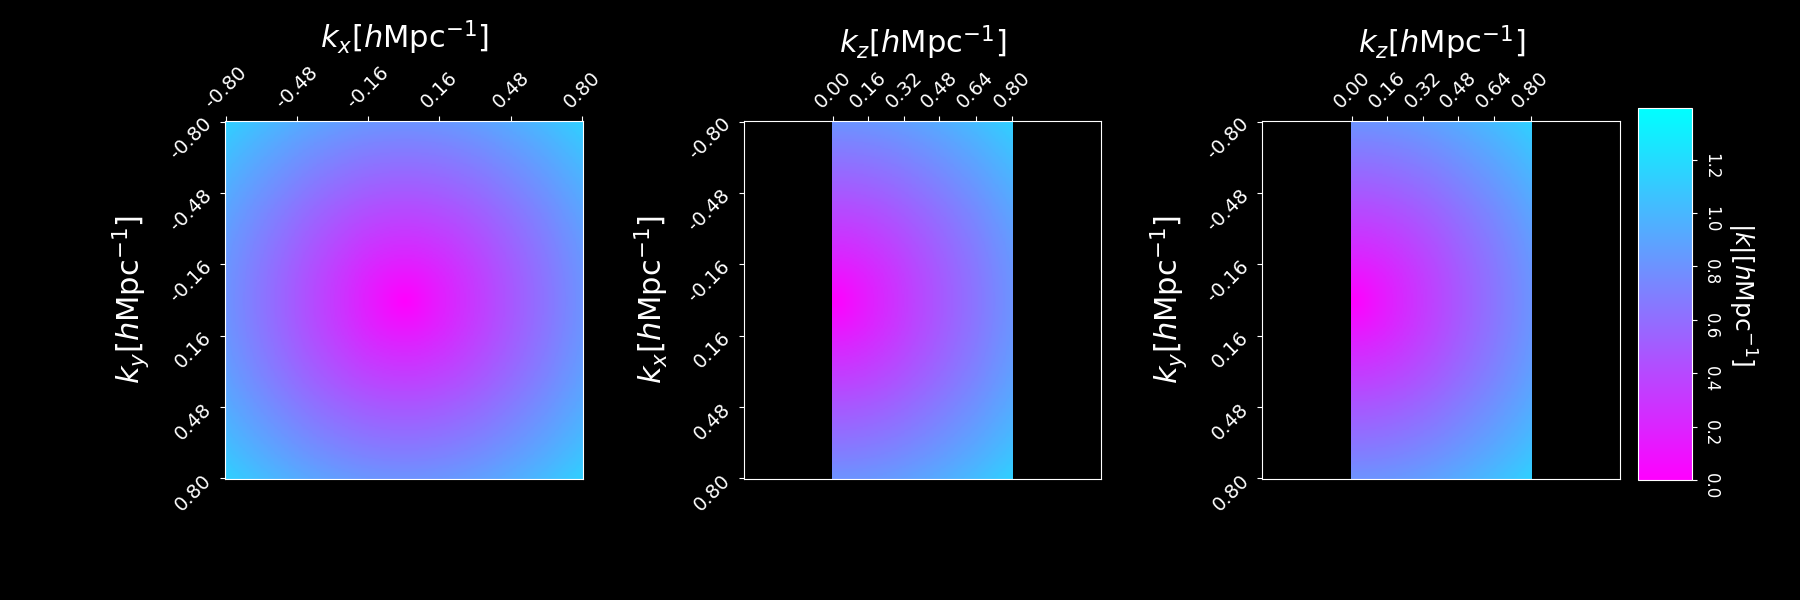

In [22]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0] ;ax2 = axes[1];ax3 = axes[2]
div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(k_radius[:,:,0],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=k_radius.max()*fact))
    im2 = ax2.matshow(k_radius[:,indcut,:],cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=k_radius.max()*fact))
    im3 = ax3.matshow(k_radius[indcut,:,:],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=k_radius.max()*fact))
else:
    im1 = ax1.matshow(k_radius[:,:,0],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k_radius.max()*fact)
    im2 = ax2.matshow(k_radius[:,indcut,:],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k_radius.max()*fact)
    im3 = ax3.matshow(k_radius[indcut,:,:],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k_radius.max()*fact)

# Colorbar setting # can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.get_yaxis().labelpad = 28
myCbar.set_ylabel(r"$|k| [h\mathrm{Mpc}^{-1}]$", fontsize = 18, rotation = 270)

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

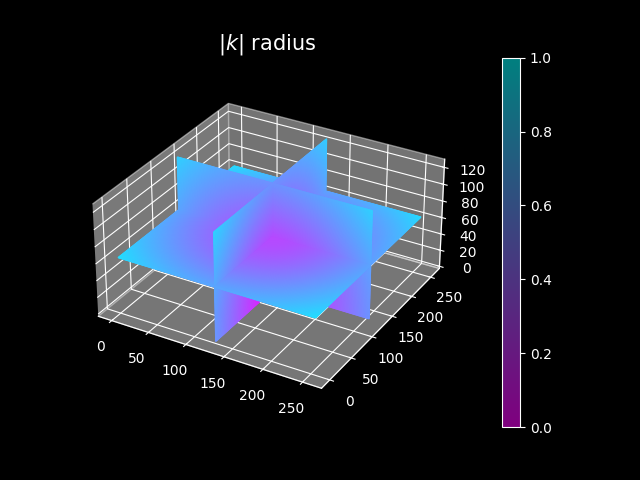

In [22]:
def plot_quadrants(ax, array, fixed_coord, cmap):
    """For a given 3d *array* plot a plane with *fixed_coord*, using four quadrants."""
    nx, ny, nz = array.shape
    index = {
        'x': (nx // 2, slice(None), slice(None)),
        'y': (slice(None), ny // 2, slice(None)),
        'z': (slice(None), slice(None), nz // 2),
    }[fixed_coord]
    plane_data = array[index]

    n0, n1 = plane_data.shape
    quadrants = [
        plane_data[:n0 // 2, :n1 // 2],
        plane_data[:n0 // 2, n1 // 2:],
        plane_data[n0 // 2:, :n1 // 2],
        plane_data[n0 // 2:, n1 // 2:]
    ]

    min_val = array.min()
    max_val = array.max()

    cmap = plt.get_cmap(cmap)

    for i, quadrant in enumerate(quadrants):
        facecolors = cmap((quadrant - min_val) / (max_val - min_val))
        #facecolors = cmap(quadrant)
        if fixed_coord == 'x':
            Y, Z = np.mgrid[0:ny // 2, 0:nz // 2]
            X = nx // 2 * np.ones_like(Y)
            Y_offset = (i // 2) * ny // 2
            Z_offset = (i % 2) * nz // 2
            A = ax.plot_surface(X, Y + Y_offset, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5, cmap = cmap)
        elif fixed_coord == 'y':
            X, Z = np.mgrid[0:nx // 2, 0:nz // 2]
            Y = ny // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Z_offset = (i % 2) * nz // 2
            A = ax.plot_surface(X + X_offset, Y, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5,cmap = cmap)
        elif fixed_coord == 'z':
            X, Y = np.mgrid[0:nx // 2, 0:ny // 2]
            Z = nz // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Y_offset = (i % 2) * ny // 2
            A = ax.plot_surface(X + X_offset, Y + Y_offset, Z, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5, cmap = cmap)
    return A


def figure_3D_array_slices(array,  titlestr,cmap=None):
    """Plot a 3d array using three intersecting centered planes."""
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(array.shape)
    A = plot_quadrants(ax, array, 'x', cmap=cmap)
    plot_quadrants(ax, array, 'y', cmap=cmap)
    plot_quadrants(ax, array, 'z', cmap=cmap)
    plt.title(titlestr, fontsize = 15)
    fig.colorbar(A, pad = 0.1)
    # divider = make_axes_locatable(ax)
    # cad = divider.append_axes("right", size="8%", pad=0.05)
    # mappable = plt.cm.ScalarMappable(cmap=cmap, cax = cad)
    # plt.colorbar(mappable)
    return fig, ax

figure_3D_array_slices(k_radius,r"$|k|$" + " radius", cmap='cool_r')
plt.show()

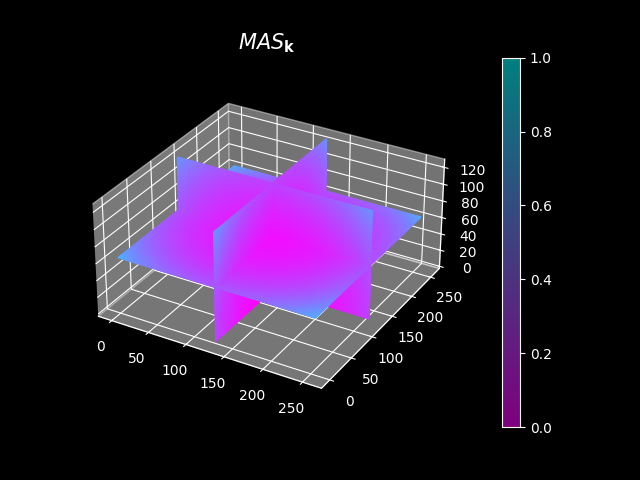

In [31]:
figure_3D_array_slices(MAS_factor,r"$MAS_{\mathbf{k}}$", cmap='cool_r')
plt.show()

### Compute $\Delta_{\mathbf{k}}$

In [23]:
delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

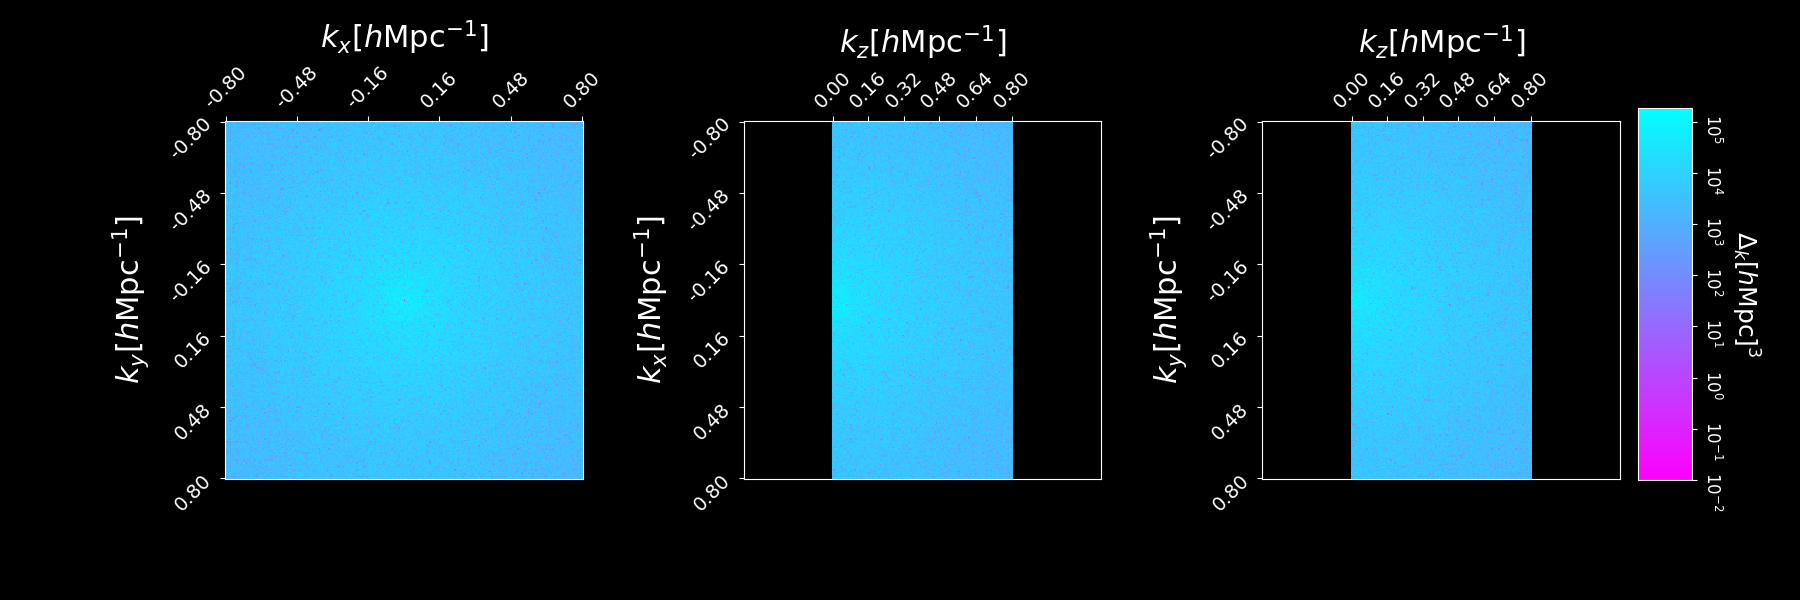

In [25]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0]; ax2 = axes[1] ; ax3 = axes[2]

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

logscale = True
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(delta_k[:,:,0]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
    im2 = ax2.matshow(abs(delta_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
    im3 = ax3.matshow(abs(delta_k[indcut,:,:]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
else:
    im1 = ax1.matshow(abs(delta_k[:,:,0]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(delta_k[:,:,0]).max())
    im2 = ax2.matshow(abs(delta_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(delta_k).max())
    im3 = ax3.matshow(abs(delta_k[indcut,:,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax =abs(delta_k).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\Delta_k [h\mathrm{Mpc}]^{3}$", fontsize = 18, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

### Compute $\frac{\gamma_k}{k^2} \times \Delta_k \equiv \Phi_k$ in 3D

In [24]:
# @jit(nopython=True) has for alias @njit
@njit
def fill_fourier_grid(weights_grid, k3D_radius , k_bins, weights1D):
    '''
    interpolate the gamma_k/k**2=weights1D to multiplty the three-dimensional Phi_k with
    '''
    for ix in numba.prange(k3D_radius.shape[0]):
        for iy in numba.prange(k3D_radius.shape[1]):
            for iz in numba.prange(k3D_radius.shape[2]):
                weights_grid[ix,iy,iz] = np.interp(k3D_radius[ix,iy,iz], k_bins, weights1D) #(x,xp,fp)
    return weights_grid

In [25]:
print(k.shape == gamma_k.shape)
weights1D = gamma_k/(k**2)

True


In [26]:
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D)

# Finally compute Phi_k
phi_k = weights_grid* delta_pm_fourier

In [27]:
print(delta_k.nbytes/(1024**2), "Mb")
print(pos_pm.nbytes/(1024**2), "Mb")
try:
    del pos_nb
except:
    pass

64.5 Mb
1536.0 Mb


### Compute $\nabla \Phi(x)$
For that, we compute the gradient in Fourier space and then IFFT.

In [28]:
grad_x_fourier = -1.0j*kx_v[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier = -1.0j*ky_v[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier = -1.0j*kz_v[np.newaxis, np.newaxis, :] * phi_k

grad_x_fourier_g = -1.0j*kx_g * phi_k
grad_y_fourier_g = -1.0j*ky_g * phi_k
grad_z_fourier_g = -1.0j*kz_g * phi_k

print((grad_x_fourier == grad_x_fourier_g).all())
print((grad_y_fourier == grad_y_fourier_g).all())
print((grad_z_fourier == grad_z_fourier_g).all())

True
True
True


In [29]:
# Initialize
start = time.time()
N_CPU = 16
arr_inx  =  pyfftw.empty_aligned((grid, grid, grid//2+1), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid//2+1), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid//2+1), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)


fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)


grad_x_real = fftw_planx(arr_inx, arr_outx)
grad_y_real = fftw_plany(arr_iny, arr_outy)
grad_z_real = fftw_planz(arr_inz, arr_outz)
end=time.time()
print("Computation: %.3f seconds"%(end-start))

Computation: 0.212 seconds


In [30]:
# Initialize
start=time.time()
N_CPU = 16
arr_inx  =  pyfftw.empty_aligned((grid, grid, grid//2+1), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid//2+1), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid//2+1), dtype=prec_out)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)

# Instantiate FFTW object
ifftw_objectx = pyfftw.builders.irfftn(arr_inx,  axes=(0,1,2), threads=N_CPU)
ifftw_objecty = pyfftw.builders.irfftn(arr_iny,  axes=(0,1,2), threads=N_CPU)
ifftw_objectz = pyfftw.builders.irfftn(arr_inz,  axes=(0,1,2), threads=N_CPU)

grad_x_real_alt = ifftw_objectx()
grad_y_real_alt = ifftw_objecty()
grad_z_real_alt = ifftw_objectz()
end=time.time()
print("Computation: %.3f seconds"%(end-start))
print("Norm of difference: ", np.linalg.norm(grad_x_real_alt - grad_x_real))

Computation: 0.325 seconds
Norm of difference:  0.0


In [31]:
print(grad_x_real.shape)
print(grad_y_real.shape)
print(grad_z_real.shape)

(256, 256, 256)
(256, 256, 256)
(256, 256, 256)


### Displace postitions in real space

In [32]:
mod 

0.10000000000000009

In [37]:
np.mod(2., 1.90)

0.10000000000000009

In [44]:
@njit
def displace_positions_nn(positions, new_positions, grad_x, grad_y, grad_z, array_length):
    '''
    Nearest neighbor computation
    '''
    N = positions.shape[0]
    print(positions.shape)
    for n in numba.prange(N):

        # Calculate at nearest voxel
        x_index = np.argmin((positions[n,0] - array_length)**2)
        y_index = np.argmin((positions[n,1] - array_length)**2)
        z_index = np.argmin((positions[n,2] - array_length)**2)
        
        new_positions[n,0] = positions[n,0] + grad_x[x_index,y_index,z_index]
        new_positions[n,1] = positions[n,1] + grad_y[x_index,y_index,z_index]
        new_positions[n,2] = positions[n,2] + grad_z[x_index,y_index,z_index]
        
    return new_positions

@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    """
    Performs trilinear interpolation on a regular 3D array using Numba.

    Args:
        data (np.ndarray): The 3D array containing the data to interpolate.
        points (np.ndarray): A 2D array where each row represents query coordinates (x, y, z).
        x_coords (np.ndarray): 1D array of x-coordinates for the data grid.
        y_coords (np.ndarray): 1D array of y-coordinates for the data grid.
        z_coords (np.ndarray): 1D array of z-coordinates for the data grid.

    Returns:
        np.ndarray: An array of interpolated values corresponding to the query points.
    """
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)

    # ASSUMING REGULAR GRIDS: Pre-calculate inverse outside the loop
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0]) 

    for i in numba.prange(num_points):
        
        x_query, y_query, z_query = points[i]

        # Indices of cube around query point
        x0_idx = np.searchsorted(x_coords, x_query, side = "left")
        y0_idx = np.searchsorted(y_coords, y_query, side = "left")
        z0_idx = np.searchsorted(z_coords, z_query, side = "left")

        # Ensure bounds are correct
        x0_idx = max(0, min(x0_idx, nx - 2))
        y0_idx = max(0, min(y0_idx, ny - 2))
        z0_idx = max(0, min(z0_idx, nz - 2))
        # x1_idx = x0_idx + 1 # not needed because regular grid !
        # y1_idx = y0_idx + 1
        # z1_idx = z0_idx + 1

        x0 = x_coords[x0_idx]
        y0 = y_coords[y0_idx]
        z0 = z_coords[z0_idx]

        # Linear interpolation weights
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv

        # Perform trilinear interpolation (hard-coded formula for 8 corners)
        c000 = data[x0_idx, y0_idx, z0_idx]
        c100 = data[x0_idx + 1, y0_idx, z0_idx]
        c010 = data[x0_idx, y0_idx + 1, z0_idx]
        c001 = data[x0_idx, y0_idx, z0_idx + 1]
        c110 = data[x0_idx + 1, y0_idx + 1, z0_idx]
        c101 = data[x0_idx + 1, y0_idx, z0_idx + 1]
        c011 = data[x0_idx, y0_idx + 1, z0_idx + 1]
        c111 = data[x0_idx + 1, y0_idx + 1, z0_idx + 1]

        interpolated_value = (
            c000 * (1 - xd) * (1 - yd) * (1 - zd) +
            c100 * xd * (1 - yd) * (1 - zd) +
            c010 * (1 - xd) * yd * (1 - zd) +
            c001 * (1 - xd) * (1 - yd) * zd +
            c110 * xd * yd * (1 - zd) +
            c101 * xd * (1 - yd) * zd +
            c011 * (1 - xd) * yd * zd +
            c111 * xd * yd * zd
        )
        interpolated_values[i] = interpolated_value

    return interpolated_values

@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z, x_c, y_c, z_c):
    '''
    3D interpolation in numba computation
    '''

    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c) #"c" for comoving coordinates
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c)
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c)

    # How to make periodic boundary conditions ?
    new_positions[:,0] = np.mod(positions[:,0] + nabla_x , x_c)
    new_positions[:,1] = np.mod(positions[:,1] + nabla_y , y_c)
    new_positions[:,2] = np.mod(positions[:,2] + nabla_z , z_c)
            
    return new_positions

In [34]:
mean_disp = np.mean(np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ))
max_disp = np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ).max()
print(mean_disp)
print(max_disp)
print(grad_x_real.dtype)

0.2626346
10.802386
float32


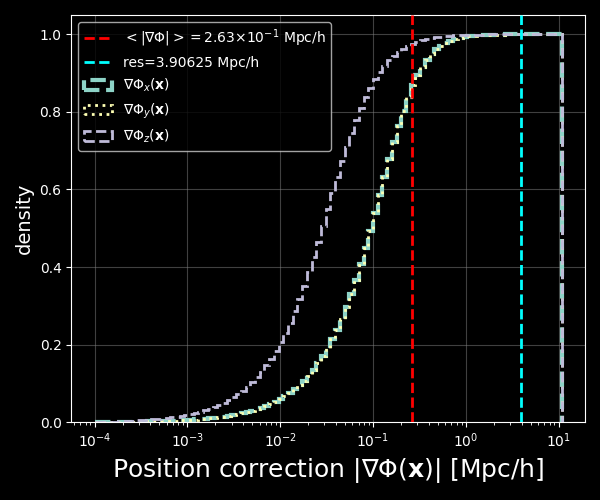

In [63]:
loghist = False
denshist = True
cumhist = 1
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 100)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.abs(grad_x_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed" , lw = 3)
ax.hist(np.abs(grad_y_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dotted", zorder = 3 )
ax.hist(np.abs(grad_z_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dashed", zorder = 4)
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
#ax.set_xlim(left = 0, right = 60.)

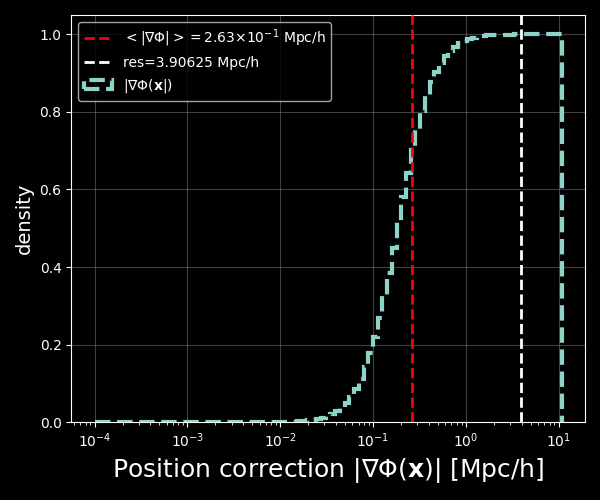

In [64]:
loghist = False
denshist = True
cumhist = 1
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 100)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "white", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ).flatten(),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$|\nabla \Phi(\mathbf{x}|)$", cumulative=cumhist, linestyle = "dashed" , lw = 3)
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
#ax.set_xlim(left = 0, right = 60.)

In [39]:
# threshold = 1.0*BoxSize/grid #voxel size
# grad_x_real[np.abs(grad_x_real)>threshold]=0.
# grad_y_real[np.abs(grad_y_real)>threshold]=0.
# grad_z_real[np.abs(grad_z_real)>threshold]=0.

# For the comoving interpolation vector, compute the grid coordinates and then the center of voxels
cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
print(length_grid.min(), length_grid.max())
comoving_length = length_grid + cell/2
print(comoving_length.min(), comoving_length.max())

0.0 996.09375
1.953125 998.046875


In [45]:
pos_disp_nn = np.empty(pos_pm.shape)

start = time.time()
pos_disp_nn = displace_positions_nn(pos_pm, pos_disp_nn, grad_x_real, grad_y_real, 
                              grad_z_real, comoving_length)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for nn displacemtn"%elapsed)

(134217728, 3)
102.32 seconds of computation for nn displacemtn


In [34]:
pos_disp_interp = np.empty(pos_pm.shape)

start = time.time()
pos_disp_interp = displace_positions_interp(pos_pm, pos_disp_interp, grad_x_real, grad_y_real, 
                              grad_z_real, comoving_length, comoving_length, comoving_length)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for interp displacement"%elapsed)

33.32 seconds of computation for interp displacement


In [37]:
print(np.mean(pos_disp_nn - pos_pm))
print(np.mean(pos_disp_interp - pos_pm))
del pos_pm

0.030640220774416024
0.06738437378314442


In [46]:
print(pos_disp_interp.nbytes/(1024**2), "Mb")
pos_disp_interp.astype("float32").dtype
print(pos_disp_interp.astype("float32").nbytes/(1024**2), "Mb")
print(pos_disp_interp.max())
print(pos_disp_nn.max())

3072.0 Mb
1536.0 Mb
1025.320556640625
1007.5358276367188


### Examine power spectrum of displaced particles

In [47]:
# N-body (=target if no emulator)
delta_disp_nn = get_delta(pos=pos_disp_nn.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_disp_nn, Pk_disp_nn, _, _ = compute_Pk(delta_disp_nn, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 1.812 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds


In [48]:
del pos_disp_nn

In [ ]:
delta_disp_interp = get_delta(pos=pos_disp_interp.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_disp_interp, Pk_disp_interp, _, _ = compute_Pk(delta_disp_interp, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

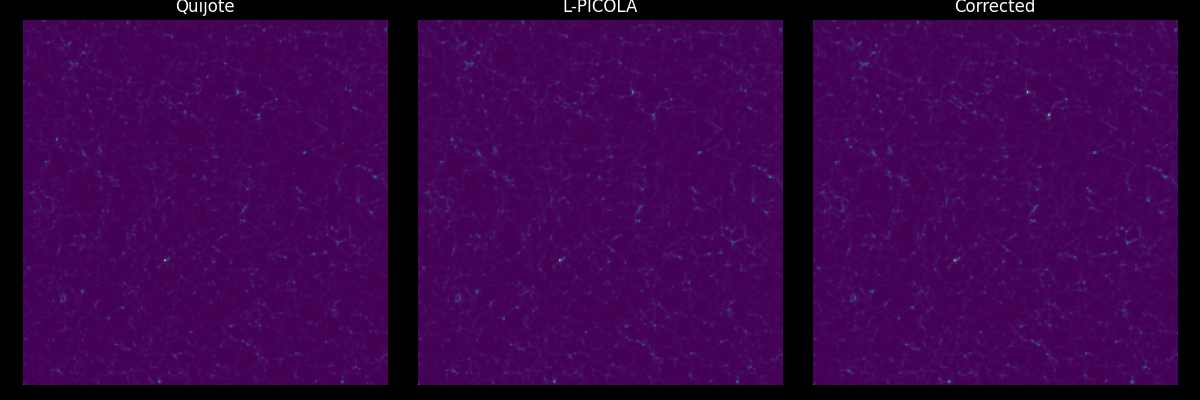

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# plt.imshow(delta[0])
ind=50
axes[0].imshow(delta_nb[ind])
axes[0].set_title("Quijote")

axes[1].imshow(delta_pm[ind])
axes[1].set_title("L-PICOLA")

axes[2].imshow(delta_disp_interp[ind])
axes[2].set_title("Corrected")

for ax in axes:
    ax.axis("off")

plt.tight_layout()  # Adjust layout
plt.show()

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

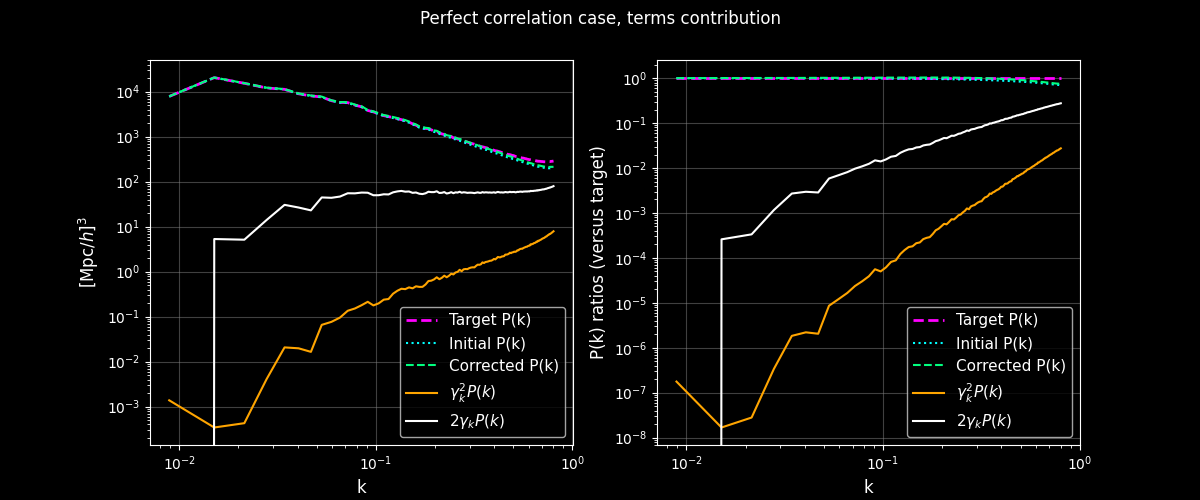

In [43]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k, Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k, Pk_disp[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_target[inds]/Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_target[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, Pk_disp[inds]/Pk_target[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_target[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_target[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

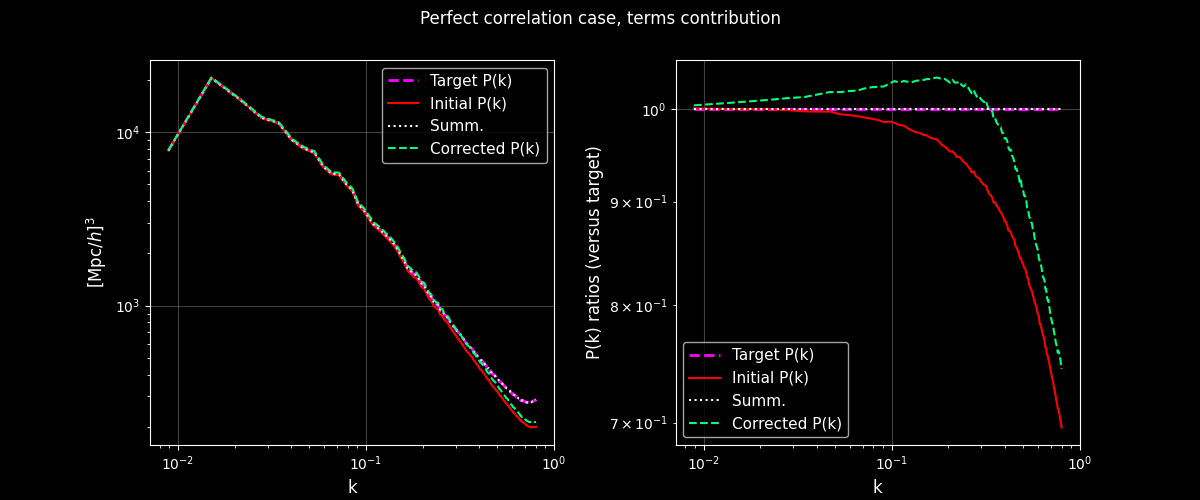

In [44]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

summ_th =  coeffs[:,0]*(roots[:,1].real)**2+coeffs[:,1]*roots[:,1].real+ Pk_pm[inds]

ax1.plot(k, Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "red", lw = 1.5, label = "Initial P(k)", zorder = 5)
ax1.plot(k, summ_th, color = "white", lw = 1.5, label = "Summ.", ls = "dotted", zorder = 5)
ax1.plot(k, Pk_disp[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_target[inds]/Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_target[inds], color = "red", lw = 1.5, label = "Initial P(k)", zorder = 5)
ax2.plot(k, summ_th/Pk_target[inds], color = "white", lw = 1.5, label = "Summ.", ls = "dotted", zorder = 10)
ax2.plot(k, Pk_disp[inds]/Pk_target[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)
plt.subplots_adjust(wspace = 0.3)

plt.suptitle("Perfect correlation case, terms contribution")


Computing power spectra of the fields...
Time FFTS = 0.58
Time loop = 0.36
Time taken = 0.94 seconds


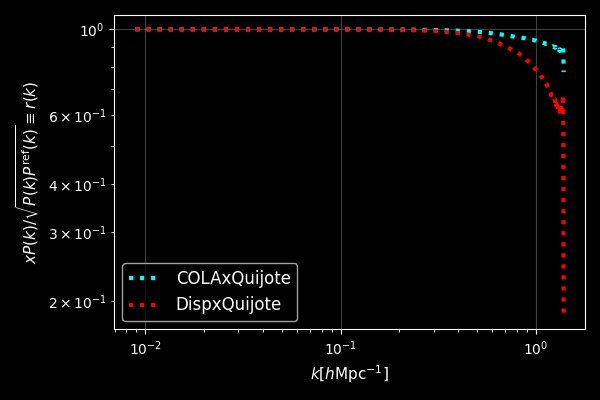

In [45]:
# Cross-Spectrum
k_Xd, Pk_Xd, _, _ = compute_XPk(delta_disp, delta_nb, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rkd = Pk_Xd/np.sqrt(Pk_disp*Pk_nb)

fig, axes = plt.subplots(1,1, figsize = (6,4))
axes.plot(k_X, rk, ':', label='COLAxQuijote', zorder= 10, lw = 3, color = "cyan")
axes.plot(k_X, rkd, ':', label='DispxQuijote', zorder= 10, lw = 3, color = "red")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()

## 2-2) Partial correlation case
\begin{equation}
    \phi (k) = \frac{\gamma_k}{k^2} F_k
\end{equation}
where
\begin{equation}
    \langle F_k \Delta_{k^\prime}^\ast \rangle = r(k) \sqrt{P_\Delta(k) \times P_{F} (k)} \delta^{\rm D} (\vec{k} - \vec{k}^\prime)
\end{equation}
Choose e.g. $F$ to be the mass-weighted density field

**This is only relevant in the halo case.** :)

## 2-3) Uncorrelated case
\begin{equation}
    Q(k) = \frac{\beta_k^2}{k^4} P(k),
\end{equation}
where $\beta \geq 0$.